## 1. Setup

Povezuje Google Drive gde su trajno sačuvane ključne tačke (.npy fajlovi), splitovi i lista znakova. Pokreće se na početku svake sesije. Za obuku nam ne treba ni MediaPipe ni video snimci - sve to je odrađeno u fazi ekstrakcije, a ovde radimo samo sa gotovim tačkama.

In [ ]:
import os, glob, json, shutil
import numpy as np
import pandas as pd

if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount('/content/drive')

WORK = "/content/drive/MyDrive/asl_citizen"
print("Drive spreman. WORK =", WORK)
for split in ["train","val","test"]:
    n = len(glob.glob(f"{WORK}/keypoints/{split}/*.npy"))
    print(f"  keypoints/{split}: {n} .npy")

Drive spreman. WORK = /content/drive/MyDrive/asl_citizen
  keypoints/train: 497 .npy
  keypoints/val: 96 .npy
  keypoints/test: 380 .npy


## 2. Učitavanje tačaka i mapiranje znakova

Učitava sve .npy sekvence (svaka je niz oblika [broj_frejmova × 162]: leva
šaka 63 + desna šaka 63 + poza 36). Svakoj sekvenci dodeljuje broj klase na
osnovu znaka. Znak se čita iz CSV-a (ne iz imena fajla) da bi se izbegli
problemi sa razmacima i brojevima u nazivima.

In [ ]:
with open(f"{WORK}/selected_signs.json") as f:
    SELECTED = sorted(json.load(f))
sign_to_idx = {s: i for i, s in enumerate(SELECTED)}
idx_to_sign = {i: s for s, i in sign_to_idx.items()}
print("Broj klasa:", len(SELECTED))

# Mapa ime_fajla -> Gloss (iz CSV-a, da se izbegne problem sa razmacima)
file_to_gloss = {}
for split in ["train","val","test"]:
    df = pd.read_csv(f"{WORK}/splits/{split}.csv")
    for _, row in df.iterrows():
        file_to_gloss[os.path.splitext(row["Video file"])[0]] = row["Gloss"]

def load_split(split):
    X, y, lengths = [], [], []
    for path in sorted(glob.glob(f"{WORK}/keypoints/{split}/*.npy")):
        name = os.path.basename(path)[:-4]
        gloss = file_to_gloss.get(name)
        if gloss is None or gloss not in sign_to_idx:
            continue
        seq = np.load(path)
        if len(seq) == 0:
            continue
        X.append(seq); y.append(sign_to_idx[gloss]); lengths.append(len(seq))
    return X, np.array(y), lengths

Broj klasa: 25


## 3. Priprema sekvenci

Sekvence imaju različite dužine, a mreža traži fiksnu. Prvo se svaka sekvenca
"iseče" na deo gde su šake aktivne (uklanjaju se prazni krajevi videa gde su
ruke spuštene), pa se svede na tačno 64 frejma - duže se ravnomerno proređuju,
kraće se dopune nulama. Maska beleži koji su frejmovi pravi a koji dopuna.

In [ ]:
MAX_LEN = 64

def trim_to_hands(seq):
    """Iseče sekvencu na opseg gde su šake aktivne (ukloni prazne krajeve)."""
    has_hand = np.any(seq[:, :126] != 0, axis=1)
    if not has_hand.any():
        return seq
    first = np.argmax(has_hand)
    last  = len(has_hand) - np.argmax(has_hand[::-1])
    return seq[first:last]

def pad_or_truncate(seq, max_len=MAX_LEN):
    """Svede na tačno max_len frejmova. Duže -> ravnomerno uzorkuje. Kraće -> nule + maska."""
    T = len(seq); F = seq.shape[1]
    if T >= max_len:
        idx = np.linspace(0, T-1, max_len).astype(int)
        out = seq[idx]; mask = np.ones(max_len, dtype=np.float32)
    else:
        out = np.zeros((max_len, F), dtype=np.float32); out[:T] = seq
        mask = np.zeros(max_len, dtype=np.float32); mask[:T] = 1.0
    return out.astype(np.float32), mask

def build_split(split):
    X, y, _ = load_split(split)
    Xp = np.zeros((len(X), MAX_LEN, X[0].shape[1]), dtype=np.float32)
    M  = np.zeros((len(X), MAX_LEN), dtype=np.float32)
    for i, seq in enumerate(X):
        seq = trim_to_hands(seq)
        Xp[i], M[i] = pad_or_truncate(seq)
    return Xp, np.array(y), M

X_train, y_train, m_train = build_split("train")
X_val,   y_val,   m_val   = build_split("val")
X_test,  y_test,  m_test  = build_split("test")
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (497, 64, 162) | Val: (96, 64, 162) | Test: (380, 64, 162)


## 4. Normalizacija

Sirove koordinate zavise od toga gde osoba stoji u kadru. Da bi model učio
oblik pokreta a ne poziciju, svaki frejm se centrira oko sredine ramena i
skalira širinom ramena. Time isti znak izgleda isto bez obzira na položaj i
udaljenost osobe - što je ključno da model radi i na novoj kameri.

In [ ]:
def normalize(X, mask):
    """Centriraj oko sredine ramena, skaliraj širinom ramena.
       Zaštita: minimalni razmak ramena + klipovanje ekstremnih vrednosti."""
    Xn = X.copy()
    N, T, F = X.shape
    for i in range(N):
        for t in range(T):
            if mask[i, t] == 0:
                continue
            frame = X[i, t].reshape(-1, 3)
            l_sh, r_sh = frame[42], frame[43]
            center = (l_sh + r_sh) / 2
            scale = np.linalg.norm(l_sh - r_sh)
            scale = max(scale, 0.1)               # <-- zaštita: razmak ne sme biti premali
            nonzero = np.any(frame != 0, axis=1)
            frame[nonzero] = (frame[nonzero] - center) / scale
            Xn[i, t] = frame.flatten()
    Xn = np.clip(Xn, -5.0, 5.0)
    return Xn.astype(np.float32)

X_train_n = normalize(X_train, m_train)
X_val_n   = normalize(X_val,   m_val)
X_test_n  = normalize(X_test,  m_test)

# Provera da je sad sve u redu
print("Min/max posle popravke:", float(X_train_n.min()), float(X_train_n.max()))
print("Sekvenci sa vrednošću > 50:", int((np.abs(X_train_n).max(axis=(1,2)) > 50).sum()))

Min/max posle popravke: -5.0 5.0
Sekvenci sa vrednošću > 50: 0


Definicija lstm

In [ ]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, in_dim=162, hidden=128, n_classes=25, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out.mean(dim=1)
        return self.head(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("LSTM definisan. Uređaj:", device)

LSTM definisan. Uređaj: cuda


## 5. LSTM model i obuka

Prvi model: dvosmerna LSTM mreža koja čita sekvencu ključnih tačaka i
prepoznaje znak. LSTM je pogodan za sekvencijalne podatke jer pamti tok
pokreta kroz vreme. Trenira se na trening skupu, bira najbolji model po
tačnosti na validacionom skupu, i na kraju meri tačnost na test skupu
(osobe koje model nije video tokom obuke).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Uređaj:", device)

#  Podaci u DataLoader-e
def make_loader(X, y, batch=32, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle)

train_loader = make_loader(X_train_n, y_train, shuffle=True)
val_loader   = make_loader(X_val_n,   y_val)
test_loader  = make_loader(X_test_n,  y_test)

#  LSTM model
class LSTMClassifier(nn.Module):
    def __init__(self, in_dim=162, hidden=128, n_classes=25, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, num_layers=n_layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        out, _ = self.lstm(x)          # [B, T, hidden*2]
        out = out.mean(dim=1)          # prosek preko vremena
        return self.head(out)

model = LSTMClassifier(n_classes=len(SELECTED)).to(device)
print("Parametara:", sum(p.numel() for p in model.parameters()))

#  Petlja obuke
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total

best_val = 0.0
for epoch in range(40):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    val_acc = evaluate(val_loader)
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), f"{WORK}/lstm_best.pt")
    if (epoch + 1) % 5 == 0:
        print(f"Epoha {epoch+1:2d}  loss={total_loss/len(train_loader):.3f}  val_acc={val_acc:.3f}")

print(f"\nNajbolja val tačnost: {best_val:.3f}")
print(f"Test tačnost: {evaluate(test_loader):.3f}")

Uređaj: cuda
Parametara: 730393
Epoha  5  loss=2.126  val_acc=0.365
Epoha 10  loss=1.505  val_acc=0.490
Epoha 15  loss=1.109  val_acc=0.552
Epoha 20  loss=0.888  val_acc=0.677
Epoha 25  loss=0.721  val_acc=0.625
Epoha 30  loss=0.568  val_acc=0.688
Epoha 35  loss=0.401  val_acc=0.708
Epoha 40  loss=0.365  val_acc=0.667

Najbolja val tačnost: 0.708
Test tačnost: 0.637


## 6. Konfuziona matrica

Pokazuje koje znakove model tačno prepoznaje, a koje međusobno meša, na test
skupu (osobe koje nije video tokom obuke).

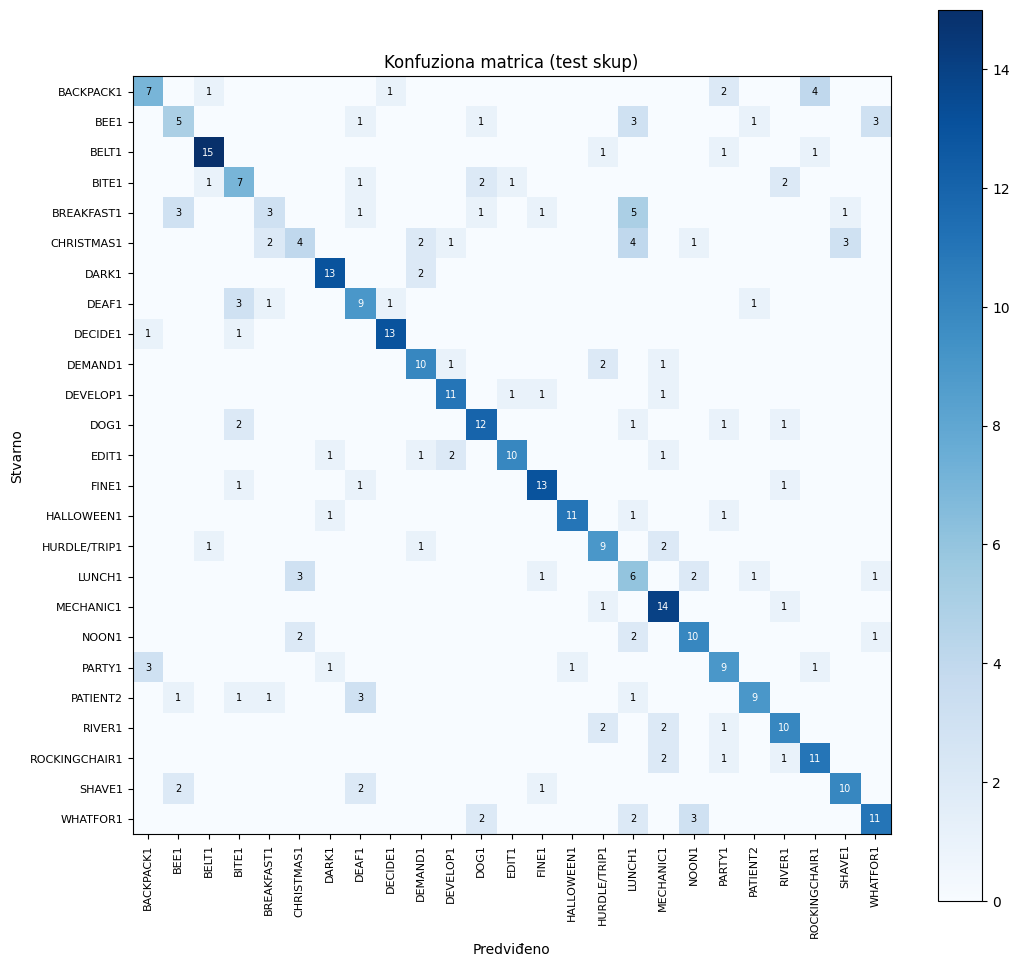

Najčešće zamene (stvarno -> predviđeno):
  BREAKFAST1 -> LUNCH1: 5x
  CHRISTMAS1 -> LUNCH1: 4x
  BACKPACK1 -> ROCKINGCHAIR1: 4x
  WHATFOR1 -> NOON1: 3x
  PATIENT2 -> DEAF1: 3x
  PARTY1 -> BACKPACK1: 3x
  LUNCH1 -> CHRISTMAS1: 3x
  DEAF1 -> BITE1: 3x


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predikcije na test skupu
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).argmax(1).cpu().numpy()
        all_pred.extend(pred)
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_pred, labels=range(len(SELECTED)))

# Crtanje
fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(SELECTED))); ax.set_yticks(range(len(SELECTED)))
ax.set_xticklabels(SELECTED, rotation=90, fontsize=8)
ax.set_yticklabels(SELECTED, fontsize=8)
ax.set_xlabel("Predviđeno"); ax.set_ylabel("Stvarno")
ax.set_title("Konfuziona matrica (test skup)")

for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

# Najčešće greške (parovi koji se mešaju)
print("Najčešće zamene (stvarno -> predviđeno):")
errors = []
for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        if i != j and cm[i,j] > 0:
            errors.append((cm[i,j], SELECTED[i], SELECTED[j]))
for cnt, a, b in sorted(errors, reverse=True)[:8]:
    print(f"  {a} -> {b}: {cnt}x")

## 7. Augmentacija podataka

Imamo malo primera po znaku (~20), pa model lako "nauči napamet" trening skup.
Augmentacija to ublažava: pri svakom prolasku kroz trening, svaka sekvenca se
malo izmeni - blaga rotacija, skaliranje, pomeranje, šum na koordinate i
variranje brzine pokreta. Tako model svaki put vidi malo drugačiju verziju
istog znaka i uči šta je suština pokreta, a ne tačne koordinate konkretnog
snimka. Pošto radimo sa tačkama (a ne slikama), ove izmene su brze i rade se
samo na trening skupu - val i test ostaju netaknuti.

In [ ]:
import torch

def augment_sequence(x, mask):
    """x: [T, 162] tenzor (normalizovana sekvenca), mask: [T].
       Vraća augmentiranu kopiju. Primenjuje se SAMO na trening."""
    x = x.clone()
    T, F = x.shape
    pts = x.view(T, -1, 3)          # [T, 54, 3] — 54 tačke × (x,y,z)

    # 1. Blaga rotacija u ravni (oko z-ose)
    ang = (torch.rand(1).item() - 0.5) * 0.4      # ±0.2 rad ≈ ±11°
    c, s = torch.cos(torch.tensor(ang)), torch.sin(torch.tensor(ang))
    xy = pts[..., :2].clone()
    pts[..., 0] = xy[..., 0]*c - xy[..., 1]*s
    pts[..., 1] = xy[..., 0]*s + xy[..., 1]*c

    # 2. Skaliranje
    scale = 1.0 + (torch.rand(1).item() - 0.5) * 0.3   # 0.85–1.15
    pts *= scale

    # 3. Pomeranje (translacija)
    shift = (torch.rand(1, 1, 3) - 0.5) * 0.1
    pts += shift

    # 4. Šum na koordinate
    pts += torch.randn_like(pts) * 0.01

    x = pts.view(T, F)
    zero_mask = (x.abs().view(T, -1, 3).sum(-1, keepdim=True) < 1e-6)
    return x

class AugmentedDataset(torch.utils.data.Dataset):
    """Dataset koji augmentira u letu. train=True -> augmentira, inače ne."""
    def __init__(self, X, y, m, train=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.m = torch.tensor(m, dtype=torch.float32)
        self.train = train
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = self.X[i]
        if self.train:
            x = augment_sequence(x, self.m[i])
        return x, self.y[i]

# Novi loaderi sa augmentacijom na trening skupu
from torch.utils.data import DataLoader
train_loader = DataLoader(AugmentedDataset(X_train_n, y_train, m_train, train=True),
                          batch_size=32, shuffle=True)
val_loader   = DataLoader(AugmentedDataset(X_val_n,   y_val,   m_val,   train=False),
                          batch_size=32)
test_loader  = DataLoader(AugmentedDataset(X_test_n,  y_test,  m_test,  train=False),
                          batch_size=32)
print("Augmentacija uključena na trening skupu. Val i test ostaju čisti.")

Augmentacija uključena na trening skupu. Val i test ostaju čisti.


## 5b. Obuka sa augmentacijom (više epoha)

Isti LSTM model, ali sad trenira na augmentovanim podacima i kroz više epoha
(80). Augmentovani podaci se sporije "uče napamet", pa modelu treba više
prolaza da dostigne najbolju formu. Bira se i čuva model sa najboljom
tačnošću na validacionom skupu, a na kraju se meri tačnost na test skupu -
to upoređujemo sa rezultatom bez augmentacije.

In [ ]:
model = LSTMClassifier(n_classes=len(SELECTED)).to(device)
print("Parametara:", sum(p.numel() for p in model.parameters()))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80)

def evaluate(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total

best_val = 0.0
best_test = 0.0
for epoch in range(80):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    val_acc = evaluate(val_loader)
    if val_acc > best_val:
        best_val = val_acc
        best_test = evaluate(test_loader)
        torch.save(model.state_dict(), f"{WORK}/lstm_best.pt")
    if (epoch + 1) % 10 == 0:
        print(f"Epoha {epoch+1:2d}  loss={total_loss/len(train_loader):.3f}  "
              f"val_acc={val_acc:.3f}  (najbolji val={best_val:.3f})")

print(f"\nNajbolja val tačnost: {best_val:.3f}")
print(f"Test tačnost (kod najboljeg vala): {best_test:.3f}")
print(f"Test tačnost (finalni model): {evaluate(test_loader):.3f}")

Parametara: 730393
Epoha 10  loss=1.532  val_acc=0.438  (najbolji val=0.521)
Epoha 20  loss=0.972  val_acc=0.562  (najbolji val=0.635)
Epoha 30  loss=0.492  val_acc=0.635  (najbolji val=0.656)
Epoha 40  loss=0.266  val_acc=0.625  (najbolji val=0.656)
Epoha 50  loss=0.185  val_acc=0.646  (najbolji val=0.656)
Epoha 60  loss=0.090  val_acc=0.677  (najbolji val=0.677)
Epoha 70  loss=0.067  val_acc=0.646  (najbolji val=0.688)
Epoha 80  loss=0.076  val_acc=0.656  (najbolji val=0.688)

Najbolja val tačnost: 0.688
Test tačnost (kod najboljeg vala): 0.676
Test tačnost (finalni model): 0.695


## 8. Transformer model

Drugi pristup za isti zadatak. Dok LSTM čita sekvencu redom (frejm po frejm) i
pamti tok kroz vreme, Transformer gleda sve frejmove odjednom i mehanizmom
pažnje (self-attention) uči koji su frejmovi međusobno važni. Ulaz, podaci i
augmentacija su isti kao kod LSTM-a, menja se samo arhitektura, da bismo
pošteno uporedili dva pristupa. Dodaje se i poziciono kodiranje, jer Transformer
sam po sebi ne zna redosled frejmova.

In [ ]:
import math

class PositionalEncoding(nn.Module):
    """Dodaje informaciju o poziciji frejma u sekvenci."""
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(self, in_dim=162, d_model=128, n_heads=4, n_layers=3,
                 n_classes=25, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_LEN)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2,
            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
    def forward(self, x):
        x = self.input_proj(x)        # [B, T, d_model]
        x = self.pos_enc(x)
        x = self.encoder(x)           # [B, T, d_model]
        x = x.mean(dim=1)             # prosek preko vremena
        return self.head(x)

tmodel = TransformerClassifier(n_classes=len(SELECTED)).to(device)
print("Transformer parametara:", sum(p.numel() for p in tmodel.parameters()))

Transformer parametara: 438297


Definicija transformera

In [ ]:
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerClassifier(nn.Module):
    def __init__(self, in_dim=162, d_model=128, n_heads=4, n_layers=3,
                 n_classes=25, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=MAX_LEN)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model*2,
            dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.head(x)

print("Transformer definisan.")

Transformer definisan.


## 8b. Obuka Transformera (sa stabilizacijom)

Transformeri su skloni nestabilnosti na početku obuke - gradijenti mogu da
"eksplodiraju" (loss postane nan). Zato dodajemo: odsecanje gradijenata
(gradient clipping), nižu početnu stopu učenja i kratko zagrevanje (warmup) u
prvih nekoliko epoha. Ostalo je isto kao kod LSTM-a, da poređenje ostane
pošteno.

In [ ]:
tmodel = TransformerClassifier(n_classes=len(SELECTED)).to(device)
print("Transformer parametara:", sum(p.numel() for p in tmodel.parameters()))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(tmodel.parameters(), lr=2e-4, weight_decay=1e-4)
def evaluate_model(m, loader):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = m(xb).argmax(1)
            correct += (pred == yb).sum().item()
            total += len(yb)
    return correct / total
EPOCHS = 80
WARMUP = 8
def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    prog = (epoch - WARMUP) / (EPOCHS - WARMUP)
    return 0.5 * (1 + math.cos(math.pi * prog))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_val_t = 0.0
best_test_t = 0.0
best_state = None
for epoch in range(EPOCHS):
    tmodel.train()
    total_loss = 0; n_batches = 0; skipped = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = tmodel(xb)
        loss = criterion(out, yb)

        # ZAŠTITA: ako je loss nan/inf, preskoči ovaj batch (ne kvari model)
        if not torch.isfinite(loss):
            skipped += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(tmodel.parameters(), max_norm=0.5)
        optimizer.step()
        total_loss += loss.item(); n_batches += 1
    scheduler.step()

    val_acc = evaluate_model(tmodel, val_loader)
    if val_acc > best_val_t:
        best_val_t = val_acc
        best_test_t = evaluate_model(tmodel, test_loader)
        best_state = {k: v.cpu().clone() for k, v in tmodel.state_dict().items()}
    if (epoch + 1) % 10 == 0:
        avg = total_loss/n_batches if n_batches else float('nan')
        print(f"Epoha {epoch+1:2d}  loss={avg:.3f}  val_acc={val_acc:.3f}  "
              f"(najbolji val={best_val_t:.3f}){'  [preskočeno '+str(skipped)+']' if skipped else ''}")

# Sačuvaj najbolji
if best_state is not None:
    torch.save(best_state, f"{WORK}/transformer_best.pt")
print(f"\nTransformer — najbolji val: {best_val_t:.3f}")
print(f"Transformer — test (kod najboljeg vala): {best_test_t:.3f}")

Transformer parametara: 438297
Epoha 10  loss=2.540  val_acc=0.375  (najbolji val=0.375)
Epoha 20  loss=1.711  val_acc=0.531  (najbolji val=0.531)
Epoha 30  loss=1.218  val_acc=0.667  (najbolji val=0.667)
Epoha 40  loss=0.919  val_acc=0.708  (najbolji val=0.708)
Epoha 50  loss=0.715  val_acc=0.771  (najbolji val=0.771)
Epoha 60  loss=0.619  val_acc=0.771  (najbolji val=0.781)
Epoha 70  loss=0.532  val_acc=0.771  (najbolji val=0.781)
Epoha 80  loss=0.523  val_acc=0.750  (najbolji val=0.781)

Transformer — najbolji val: 0.781
Transformer — test (kod najboljeg vala): 0.753


## 9. Konfuziona matrica Transformera

Ista analiza kao za LSTM, ali za Transformer model. Učitava se najbolji
sačuvani Transformer i meri na test skupu. Poredeći ovu matricu sa LSTM-ovom,
vidimo da li dva modela greše na istim parovima znakova (slični pokreti) ili
na različitim, što govori uče li slične reprezentacije.

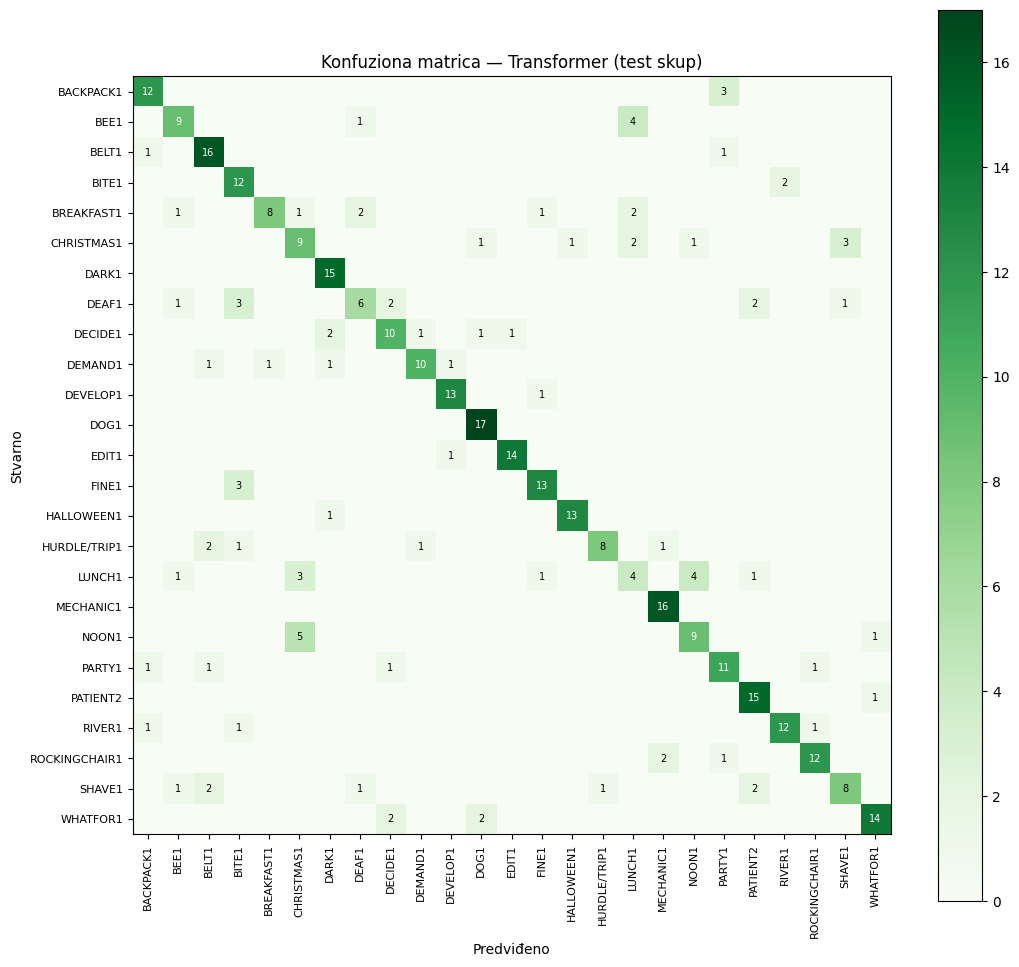

Najčešće zamene Transformera (stvarno -> predviđeno):
  NOON1 -> CHRISTMAS1: 5x
  LUNCH1 -> NOON1: 4x
  BEE1 -> LUNCH1: 4x
  LUNCH1 -> CHRISTMAS1: 3x
  FINE1 -> BITE1: 3x
  DEAF1 -> BITE1: 3x
  CHRISTMAS1 -> SHAVE1: 3x
  BACKPACK1 -> PARTY1: 3x


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Učitaj najbolji Transformer
tmodel = TransformerClassifier(n_classes=len(SELECTED)).to(device)
tmodel.load_state_dict(torch.load(f"{WORK}/transformer_best.pt"))
tmodel.eval()

all_pred, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = tmodel(xb).argmax(1).cpu().numpy()
        all_pred.extend(pred); all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_pred, labels=range(len(SELECTED)))

fig, ax = plt.subplots(figsize=(11, 10))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(len(SELECTED))); ax.set_yticks(range(len(SELECTED)))
ax.set_xticklabels(SELECTED, rotation=90, fontsize=8)
ax.set_yticklabels(SELECTED, fontsize=8)
ax.set_xlabel("Predviđeno"); ax.set_ylabel("Stvarno")
ax.set_title("Konfuziona matrica — Transformer (test skup)")
for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        if cm[i,j] > 0:
            ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i,j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

print("Najčešće zamene Transformera (stvarno -> predviđeno):")
errors = []
for i in range(len(SELECTED)):
    for j in range(len(SELECTED)):
        if i != j and cm[i,j] > 0:
            errors.append((cm[i,j], SELECTED[i], SELECTED[j]))
for cnt, a, b in sorted(errors, reverse=True)[:8]:
    print(f"  {a} -> {b}: {cnt}x")

## 10. Poređenje modela (po znaku) i finalna tabela

Računa tačnost po svakom znaku za oba modela i ukupne rezultate. Tabela po
znaku pokazuje koje znakove svaki model prepoznaje dobro, a koje teško, što
je korisno za izbor znakova za demo i za diskusiju u izveštaju.

In [ ]:
import pandas as pd

def per_class_accuracy(m):
    m.eval()
    correct = np.zeros(len(SELECTED)); total = np.zeros(len(SELECTED))
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = m(xb).argmax(1).cpu().numpy()
            for t, p in zip(yb.numpy(), pred):
                total[t] += 1
                if t == p: correct[t] += 1
    return correct / np.maximum(total, 1), total

# Učitaj oba najbolja modela
lstm = LSTMClassifier(n_classes=len(SELECTED)).to(device)
lstm.load_state_dict(torch.load(f"{WORK}/lstm_best.pt")); lstm.eval()
tmodel.load_state_dict(torch.load(f"{WORK}/transformer_best.pt")); tmodel.eval()

acc_lstm, totals = per_class_accuracy(lstm)
acc_trans, _     = per_class_accuracy(tmodel)

# Tabela po znaku
df = pd.DataFrame({
    "Znak": SELECTED,
    "Test primera": totals.astype(int),
    "LSTM tačnost": (acc_lstm*100).round(0).astype(int),
    "Transformer tačnost": (acc_trans*100).round(0).astype(int),
}).sort_values("Transformer tačnost")
print(df.to_string(index=False))

# Ukupno
def overall(m):
    correct = total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            pred = m(xb).argmax(1).cpu()
            correct += (pred == yb).sum().item(); total += len(yb)
    return correct/total

print("\n=== UKUPNO (test) ===")
print(f"LSTM:        {overall(lstm)*100:.1f}%  ({sum(p.numel() for p in lstm.parameters()):,} parametara)")
print(f"Transformer: {overall(tmodel)*100:.1f}%  ({sum(p.numel() for p in tmodel.parameters()):,} parametara)")

         Znak  Test primera  LSTM tačnost  Transformer tačnost
       LUNCH1            14            29                   29
        DEAF1            15            67                   40
   CHRISTMAS1            17            24                   53
   BREAKFAST1            15            27                   53
       SHAVE1            15            73                   53
        NOON1            15            73                   60
 HURDLE/TRIP1            13            85                   62
         BEE1            14            43                   64
      DECIDE1            15            73                   67
      DEMAND1            14            79                   71
       PARTY1            15            67                   73
     WHATFOR1            18            78                   78
ROCKINGCHAIR1            15            60                   80
       RIVER1            15            67                   80
    BACKPACK1            15            67              

In [ ]:
import pandas as pd
WORK = "/content/drive/MyDrive/asl_citizen"
parts = {}
for split in ["train","val","test"]:
    df = pd.read_csv(f"{WORK}/splits/{split}.csv")
    parts[split] = set(df["Participant ID"].unique())
print("Učesnika train:", len(parts["train"]), "val:", len(parts["val"]), "test:", len(parts["test"]))
print("Preklapanje train∩test:", parts["train"] & parts["test"])
print("Preklapanje train∩val:",  parts["train"] & parts["val"])

Učesnika train: 35 val: 6 test: 11
Preklapanje train∩test: set()
Preklapanje train∩val: set()


## 11. Vizuelizacija skeleta (replay sačuvane sekvence)

Animira "čovečuljka" od ključnih tačaka iz jedne sačuvane sekvence, isto što
model vidi: ramena, ruke i prsti spojeni linijama, kroz vreme. Ispod animacije
ispisuje se i predikcija modela za tu sekvencu.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import numpy as np

# Veze između tačaka (da nacrtamo linije skeleta)
# Prsti šake: koren(0) -> svaki prst po 4 zgloba
HAND_BONES = [(0,1),(1,2),(2,3),(3,4), (0,5),(5,6),(6,7),(7,8),
              (0,9),(9,10),(10,11),(11,12), (0,13),(13,14),(14,15),(15,16),
              (0,17),(17,18),(18,19),(19,20)]

def get_frame_points(seq, t):
    """Vrati (leva_šaka[21,3], desna[21,3], poza[12,3]) za frejm t."""
    f = seq[t]
    left  = f[0:63].reshape(21,3)
    right = f[63:126].reshape(21,3)
    pose  = f[126:162].reshape(12,3)
    return left, right, pose

def animate_sequence(seq, title=""):
    fig, ax = plt.subplots(figsize=(5,6))
    ax.set_xlim(-2, 2); ax.set_ylim(2, -2)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title)

    def draw(t):
        ax.clear()
        ax.set_xlim(-2, 2); ax.set_ylim(2, -2)
        ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)
        left, right, pose = get_frame_points(seq, t)

        # ramena i ruke (poza) - tačke 0,1 su ramena
        if np.any(pose != 0):
            ax.plot(pose[:,0], pose[:,1], 'o', color='#1D9E75', ms=6)
        # leva šaka
        if np.any(left != 0):
            for a,b in HAND_BONES:
                ax.plot([left[a,0],left[b,0]],[left[a,1],left[b,1]], '-', color='#378ADD', lw=1)
            ax.plot(left[:,0], left[:,1], 'o', color='#378ADD', ms=3)
        # desna šaka
        if np.any(right != 0):
            for a,b in HAND_BONES:
                ax.plot([right[a,0],right[b,0]],[right[a,1],right[b,1]], '-', color='#D4537E', lw=1)
            ax.plot(right[:,0], right[:,1], 'o', color='#D4537E', ms=3)
        return []

    anim = animation.FuncAnimation(fig, draw, frames=len(seq), interval=80)
    plt.close()
    return HTML(anim.to_jshtml())

idx = 10   # promeniti broj da vidimo i druge znakove
seq = X_test_n[idx]
true_sign = SELECTED[y_test[idx]]

# Predikcija modela (Transformer)
tmodel.eval()
with torch.no_grad():
    x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    pred_idx = tmodel(x).argmax(1).item()
pred_sign = SELECTED[pred_idx]

print(f"Stvarni znak: {true_sign}")
print(f"Model predviđa: {pred_sign}  {'✓ TAČNO' if pred_sign==true_sign else '✗ pogrešno'}")

animate_sequence(seq, title=f"stvarno: {true_sign} | model: {pred_sign}")

NameError: name 'tmodel' is not defined

## 12. DEMONSTRACIJA — obučeni model na karakterističnim primerima

Učitava sačuvane obučene modele sa diska i pušta ih na primere iz test skupa
(osobe koje model nije video tokom obuke). Prikazuje stvarni znak, predikciju
oba modela i sigurnost predikcije.

In [ ]:
import torch
import numpy as np

# Učitaj SAČUVANE obučene modele sa diska
lstm = LSTMClassifier(n_classes=len(SELECTED)).to(device)
lstm.load_state_dict(torch.load(f"{WORK}/lstm_best.pt"))
lstm.eval()

trans = TransformerClassifier(n_classes=len(SELECTED)).to(device)
trans.load_state_dict(torch.load(f"{WORK}/transformer_best.pt"))
trans.eval()
print("Oba obučena modela učitana sa diska\n")

def predikcija(model, seq):
    with torch.no_grad():
        x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        probs = torch.softmax(model(x), dim=1)[0]
        idx = probs.argmax().item()
    return SELECTED[idx], probs[idx].item()*100

def demo_primer(i):
    seq = X_test_n[i]
    stvarni = SELECTED[y_test[i]]
    pl, cl = predikcija(lstm, seq)
    pt, ct = predikcija(trans, seq)
    print(f"STVARNI ZNAK: {stvarni}")
    print(f"  LSTM        -> {pl:14s} ({cl:.0f}% sigurnosti)  {'TACNO' if pl==stvarni else 'pogresno'}")
    print(f"  Transformer -> {pt:14s} ({ct:.0f}% sigurnosti)  {'TACNO' if pt==stvarni else 'pogresno'}")
    print("-"*60)

print("="*60)
print("PRIMERI KOJE MODEL POUZDANO PREPOZNAJE")
print("="*60)
for znak in ["DOG1", "DARK1", "MECHANIC1"]:
    idx = np.where(y_test == sign_to_idx[znak])[0][0]
    demo_primer(idx)

print("\n" + "="*60)
print("TEZAK PRIMER — znak koji se mesa sa slicnim")
print("="*60)
for znak in ["RIVER1"]:
    idx = np.where(y_test == sign_to_idx[znak])[0][0]
    demo_primer(idx)

Oba obučena modela učitana sa diska

PRIMERI KOJE MODEL POUZDANO PREPOZNAJE
STVARNI ZNAK: DOG1
  LSTM        -> DOG1           (81% sigurnosti)  TACNO
  Transformer -> DOG1           (32% sigurnosti)  TACNO
------------------------------------------------------------
STVARNI ZNAK: DARK1
  LSTM        -> DARK1          (99% sigurnosti)  TACNO
  Transformer -> DARK1          (56% sigurnosti)  TACNO
------------------------------------------------------------
STVARNI ZNAK: MECHANIC1
  LSTM        -> MECHANIC1      (99% sigurnosti)  TACNO
  Transformer -> MECHANIC1      (73% sigurnosti)  TACNO
------------------------------------------------------------

TEZAK PRIMER — znak koji se mesa sa slicnim
STVARNI ZNAK: RIVER1
  LSTM        -> RIVER1         (64% sigurnosti)  TACNO
  Transformer -> ROCKINGCHAIR1  (30% sigurnosti)  pogresno
------------------------------------------------------------


In [ ]:
# Prikaz skeleta + predikcija
idx = np.where(y_test == sign_to_idx["RIVER1"])[0][0]
seq = X_test_n[idx]
stvarni = SELECTED[y_test[idx]]
pred, conf = predikcija(trans, seq)

print(f"Stvarni znak: {stvarni}")
print(f"Model predviđa: {pred} ({conf:.0f}% sigurnosti)")
animate_sequence(seq, title=f"stvarno: {stvarni} | model: {pred}")

Stvarni znak: RIVER1
Model predviđa: ROCKINGCHAIR1 (30% sigurnosti)


In [ ]:
# Nađi primer gde Transformer GREŠI (za demonstraciju teškog slučaja)
print("Primeri gde model greši:\n")
nadjeno = 0
for i in range(len(y_test)):
    stvarni = SELECTED[y_test[i]]
    pred, conf = predikcija(trans, X_test_n[i])
    if pred != stvarni:
        print(f"  index {i}: stvarni={stvarni:14s} -> model kaže {pred:14s} ({conf:.0f}%)")
        nadjeno += 1
    if nadjeno >= 5:
        break

Primeri gde model greši:

  index 5: stvarni=RIVER1         -> model kaže ROCKINGCHAIR1  (30%)
  index 21: stvarni=LUNCH1         -> model kaže CHRISTMAS1     (72%)
  index 27: stvarni=BITE1          -> model kaže RIVER1         (66%)
  index 34: stvarni=SHAVE1         -> model kaže HURDLE/TRIP1   (38%)
  index 47: stvarni=DECIDE1        -> model kaže DARK1          (20%)


In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def animate_dva(seq1, naslov1, seq2, naslov2):
    """Prikaži dve sekvence jednu pored druge za poređenje."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

    def draw_one(ax, seq, t, naslov):
        ax.clear()
        ax.set_xlim(-2, 2); ax.set_ylim(2, -2)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(naslov, fontsize=11, weight='bold')
        f = seq[min(t, len(seq)-1)]
        left  = f[0:63].reshape(21,3)
        right = f[63:126].reshape(21,3)
        pose  = f[126:162].reshape(12,3)
        if np.any(pose != 0):
            ax.plot(pose[:,0], pose[:,1], 'o', color='#1D9E75', ms=6)
        for hand, col in [(left,'#378ADD'), (right,'#D4537E')]:
            if np.any(hand != 0):
                for a,b in HAND_BONES:
                    ax.plot([hand[a,0],hand[b,0]],[hand[a,1],hand[b,1]], '-', color=col, lw=1)
                ax.plot(hand[:,0], hand[:,1], 'o', color=col, ms=3)

    def draw(t):
        draw_one(ax1, seq1, t, naslov1)
        draw_one(ax2, seq2, t, naslov2)
        return []

    n = max(len(seq1), len(seq2))
    anim = animation.FuncAnimation(fig, draw, frames=n, interval=90)
    plt.close()
    return HTML(anim.to_jshtml())

# --- Nađi po jedan primer svakog znaka ---
idx_river = np.where(y_test == sign_to_idx["RIVER1"])[0][0]
idx_rocking = np.where(y_test == sign_to_idx["ROCKINGCHAIR1"])[0][0]

print("Poređenje znakova koje model meša:")
print(f"  Stvarni znak: RIVER  ->  model je predvideo ROCKINGCHAIR")
print("  Gledamo da li su pokreti slični...\n")

animate_dva(X_test_n[idx_river], "RIVER (stvarni)",
            X_test_n[idx_rocking], "ROCKINGCHAIR (model je rekao ovo)")

Poređenje znakova koje model meša:
  Stvarni znak: RIVER  ->  model je predvideo ROCKINGCHAIR
  Gledamo da li su pokreti slični...

